# 📉 Telecom Customer Churn — Exploratory & Diagnostic Analysis



##  Business Problem

Telecom is a subscription-driven business, and customer churn (subscribers leaving for a
competitor or cancelling service) is one of the most expensive problems a telecom company faces.
Acquiring a new customer costs far more than retaining an existing one.

- **How big is the churn problem** and how much **revenue** is at risk?
- **Who is churning** (which customer segments, contracts, tenure stages, services)?
- **Why are customers churning** (competitor offers, poor support, pricing, product gaps)?
- **Can we identify a high-risk segment early enough to intervene** (e.g. with retention offers,
  proactive support, or contract incentives) before the customer leaves?





In [123]:
# IMPORTING REQUIRED LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from google.colab import output
output.no_vertical_scroll()

<IPython.core.display.Javascript object>

## Loading Data and Libraries

Download the raw dataset and load it into a pandas DataFrame for analysis.

In [124]:
!gdown 1YxtDfEM2Cz0J3pCSBcDJ9nv0p3OZkLV-

Downloading...
From: https://drive.google.com/uc?id=1YxtDfEM2Cz0J3pCSBcDJ9nv0p3OZkLV-
To: /content/telecom_customer_churn.csv
100% 1.44M/1.44M [00:00<00:00, 57.5MB/s]


In [125]:
# Load the telecom customer churn dataset into a pandas DataFrame
df = pd.read_csv('/content/telecom_customer_churn.csv')


In [126]:
df.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [127]:
df.shape


(7043, 38)

In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   object 
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   object 
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                              3166 non-null   objec

In [129]:
# Drop columns that add little analytical value at this stage

df.drop(['Zip Code','Latitude','Longitude'],axis=1,inplace=True)

# Exploratory Data Analysis (EDA)

Before analyzing churn drivers, we first clean up data types, check for missing values and
duplicate records, and review summary statistics of the numerical fields.

### Data Cleaning & Type Optimization


In [130]:
df.nunique()

,0
Customer ID,7043
Gender,2
Age,62
Married,2
Number of Dependents,10
City,1106
Number of Referrals,12
Tenure in Months,72
Offer,5
Phone Service,2


In [131]:
# Calculate the percentage of missing values for every column

null_summary = df.isna().sum()/len(df)*100
null_summary = null_summary[null_summary>0].sort_values(ascending=False)
print(null_summary)

Churn Category                       73.463013
Churn Reason                         73.463013
Offer                                55.047565
Online Security                      21.666903
Online Backup                        21.666903
Avg Monthly GB Download              21.666903
Internet Type                        21.666903
Streaming Movies                     21.666903
Streaming TV                         21.666903
Device Protection Plan               21.666903
Premium Tech Support                 21.666903
Unlimited Data                       21.666903
Streaming Music                      21.666903
Avg Monthly Long Distance Charges     9.683374
Multiple Lines                        9.683374
dtype: float64


In [132]:
# Convert selected text/label columns to 'category' dtype for memory efficiency and faster groupby performance

df['Gender'] = df['Gender'].astype('category')
df['Married'] = df['Married'].astype('category')
df['Churn Category'] = df['Churn Category'].astype('category')


In [133]:
df.duplicated().sum()

np.int64(0)

In [134]:
df.describe()

,Age,Number of Dependents,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
count,7043.000000,7043.000000,7043.000000,7043.000000,6361.000000,5517.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,1.951867,32.386767,25.420517,26.189958,63.596131,2280.381264,1.962182,6.860713,749.099262,3034.379056
std,16.750352,0.962802,3.001199,24.542061,14.200374,19.586585,31.204743,2266.220462,7.902614,25.104978,846.660055,2865.204542
min,19.000000,0.000000,0.000000,1.000000,1.010000,2.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000
25%,32.000000,0.000000,0.000000,9.000000,13.050000,13.000000,30.400000,400.150000,0.000000,0.000000,70.545000,605.610000
50%,46.000000,0.000000,0.000000,29.000000,25.690000,21.000000,70.050000,1394.550000,0.000000,0.000000,401.440000,2108.640000
75%,60.000000,0.000000,3.000000,55.000000,37.680000,30.000000,89.750000,3786.600000,0.000000,0.000000,1191.100000,4801.145000
max,80.000000,9.000000,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


# Churn Analysis by various fields & factors.

## Overall Churn KPIs

In [135]:

# Define the analysis base (the "resolved" customer base)

churned_df = df[df['Customer Status']=='Churned']

base = df[df['Customer Status'].isin(['Churned','Stayed'])]

base['churned_flag'] = (base['Customer Status']=='Churned').astype(int)  # Binary: 1 = Churned, 0 = Stayed

churn_rate = round(base['churned_flag'].mean()*100,2)

# 'Joined' customers are brand-new and have no churn outcome yet, so they are
# excluded from churn-rate calculations to avoid biasing the results.

print(f'Total Customers: {len(df)}')
print(f'"Resolved base (analysis): {len(base)}')
print(f'  -Stayed: {(base['churned_flag']==0).sum()}')
print(f'  -Churned: {(base['churned_flag']==1).sum()}')
print(f'  -Joined (No outcome yet): {(df['Customer Status']=='Joined').sum()}')
print()
print(f'Overall Churn Rate: {churn_rate}%')


Total Customers: 7043
"Resolved base (analysis): 6589
  -Stayed: 4720
  -Churned: 1869
  -Joined (No outcome yet): 454

Overall Churn Rate: 28.37%


## Customer Status

To understand the overall scale of churn before slicing it by different customer segments.

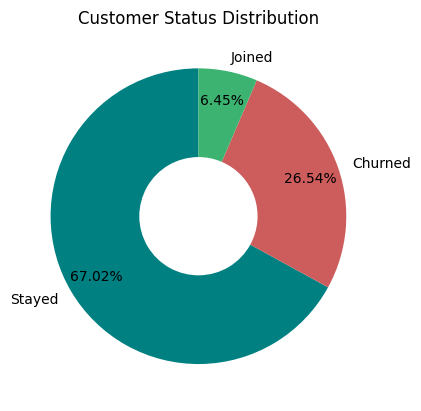

Customer Status
Stayed     4720
Churned    1869
Joined      454
Name: count, dtype: int64


In [136]:
df['Customer Status'].value_counts().plot.pie(autopct='%.2f%%',colors=['teal','indianred','mediumseagreen'],startangle=90,wedgeprops= {'width':0.6},pctdistance=0.80,ylabel='')
plt.title('Customer Status Distribution')
plt.show()
print(df['Customer Status'].value_counts())

## Household and Loyalty Signals

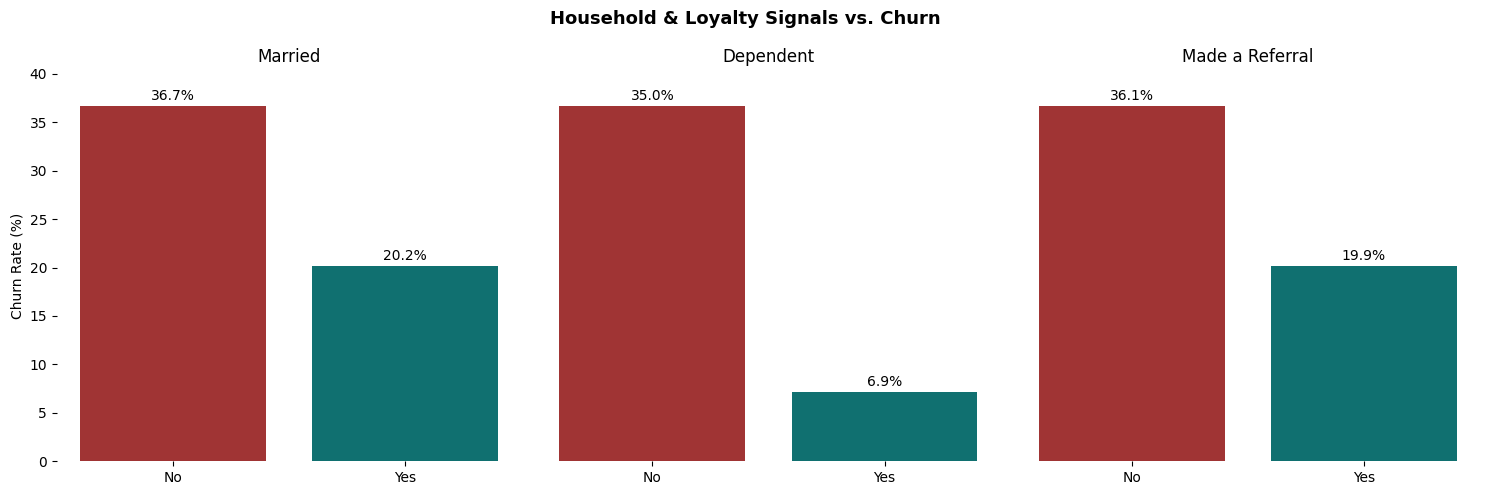

In [137]:
# churn rate by Marital Status / Dependents / Referral activity

base['Has_Dependent'] = np.where(base['Number of Dependents'] >0,'Yes','No')
base['Has_Referrals'] = np.where(base['Number of Referrals'] >0,'Yes','No')

Married = (base.groupby('Married')['churned_flag'].mean()*100).reset_index()
Dependent= (base.groupby('Has_Dependent')['churned_flag'].mean()*100).reset_index()
Referral= (base.groupby('Has_Referrals')['churned_flag'].mean()*100).reset_index()

#-----------------------------------------------------------------------------------------------------

fig, axes = plt.subplots(1,3,figsize=(15,5))
a = sns.barplot(data = Married,x='Married',y='churned_flag',palette=['firebrick','teal'],ax = axes[0])
for i in a.containers:
  a.bar_label(i,padding=2,fmt='%.1f%%')
axes[0].set_frame_on(False)
axes[0].set_ylim(0,Married['churned_flag'].max()*1.1)
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('')
axes[0].set_title('Married')


b = sns.barplot(data = Dependent,x='Has_Dependent',y='churned_flag',palette=['firebrick','teal'],ax = axes[1])
for i in b.containers:
  b.bar_label(i,padding=2,fmt='%.1f%%')
axes[1].set_frame_on(False)
axes[1].set_ylim(0,Dependent['churned_flag'].max()*1.1)
axes[1].set_ylabel('')
axes[1].set_xlabel('')
axes[1].set_yticks([])
axes[1].set_title('Dependent')


c = sns.barplot(data = Referral,x='Has_Referrals',y='churned_flag',palette=['firebrick','teal'],ax = axes[2])
for i in c.containers:
  c.bar_label(i,padding=2,fmt='%.1f%%')
axes[2].set_frame_on(False)
axes[2].set_ylim(0,Referral['churned_flag'].max()*1.1)
axes[2].set_ylabel('')
axes[2].set_xlabel('')
axes[2].set_yticks([])
axes[2].set_title('Made a Referral')
plt.suptitle('Household & Loyalty Signals vs. Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insights:** Customers who are single, have no dependents, and haven't made any referrals are significantly more likely to churn.

## Tenure Cohort

Show how churn changes across tenure cohorts from the first months of service through six years.

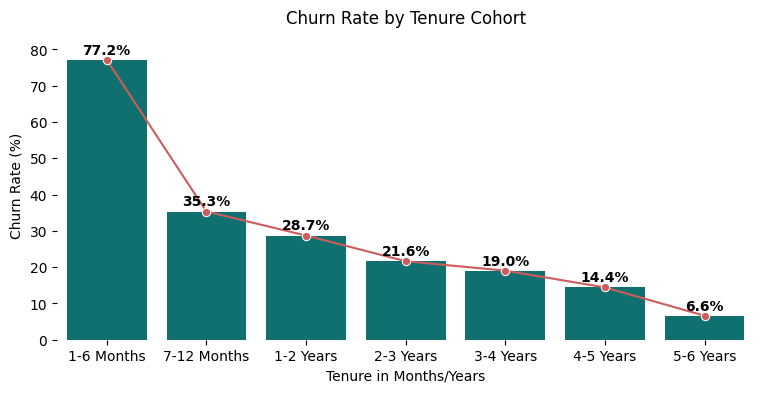

In [138]:

bins = [0, 6, 12, 24, 36, 48, 60, 72]
labels = ['1-6 Months','7-12 Months', '1-2 Years', '2-3 Years', '3-4 Years', '4-5 Years', '5-6 Years']

base['Tenure in Months/Years'] = pd.cut(base['Tenure in Months'],bins = bins,labels = labels)

month_churned = (base.groupby('Tenure in Months/Years')['churned_flag'].mean()*100).reset_index()
plt.figure(figsize=(9,4))
sns.lineplot(data=month_churned,x='Tenure in Months/Years',marker='o',y='churned_flag',color='indianred')
ax = sns.barplot(data = month_churned, x= 'Tenure in Months/Years',y='churned_flag',color='teal')
for i in ax.containers:
  ax.bar_label(i,padding=2,fmt='%.1f%%',weight='bold')
plt.title('Churn Rate by Tenure Cohort')
plt.ylabel('Churn Rate (%)')
plt.ylim(0,month_churned['churned_flag'].max()*1.1)
plt.box(False)
plt.show()

> **Insight:** Most customers are overwhelmingly leaving during their very first few months of service.

## Category and primary reason

Compare churn volume by broad churn category and the top 10 specific churn reasons.

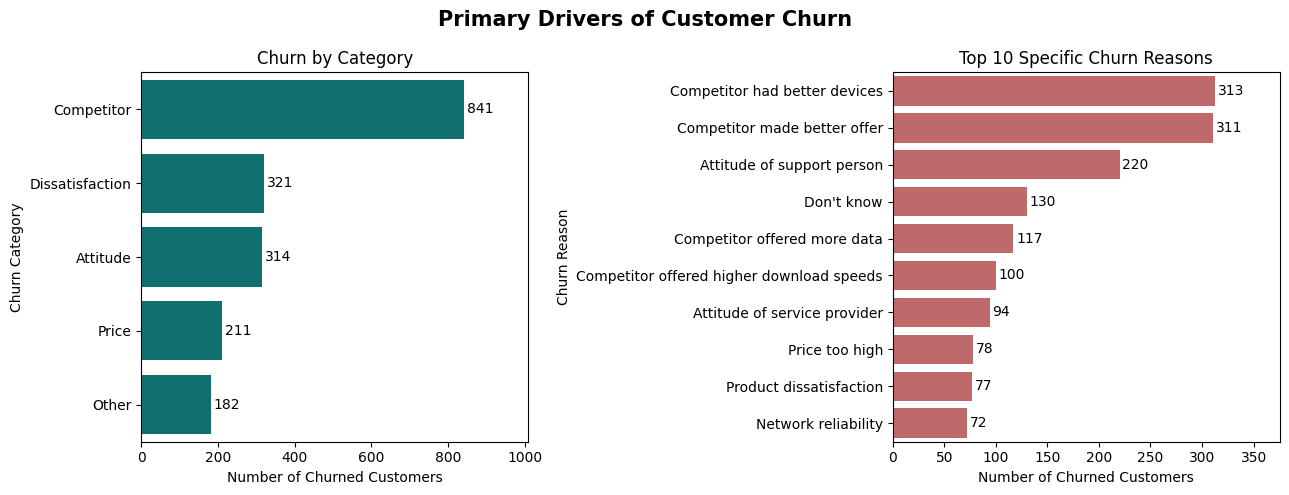

In [139]:

churn_cat = base.loc[base['churned_flag']==1,'Churn Category'].value_counts().sort_values(ascending=False).reset_index()
churn_reason = base.loc[base['churned_flag']==1,'Churn Reason'].value_counts().head(10).reset_index()  # Top 10 specific reasons


plt.figure(figsize=(13,5))
plt.subplot(1,2,1)
ax = sns.barplot(data = churn_cat, y = 'Churn Category', x ='count',color='teal', order = churn_cat['Churn Category'])
for i in ax.containers:
  ax.bar_label(i,padding=2)
plt.xlabel('Number of Churned Customers')
plt.title('Churn by Category')
plt.xlim(0,churn_cat['count'].max()*1.2)

plt.subplot(1,2,2)
ax = sns.barplot(data = churn_reason, y = 'Churn Reason', x ='count',color='indianred' )
for i in ax.containers:
  ax.bar_label(i,padding=2)
plt.xlim(0,churn_reason['count'].max() *1.2)
plt.xlabel('Number of Churned Customers')
plt.title('Top 10 Specific Churn Reasons')
plt.suptitle('Primary Drivers of Customer Churn', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


> **Insight:** CCustomers are leaving for two main reasons: competitors are offering better plans, and our customer support is frustrating them.

## Offer and Contract type

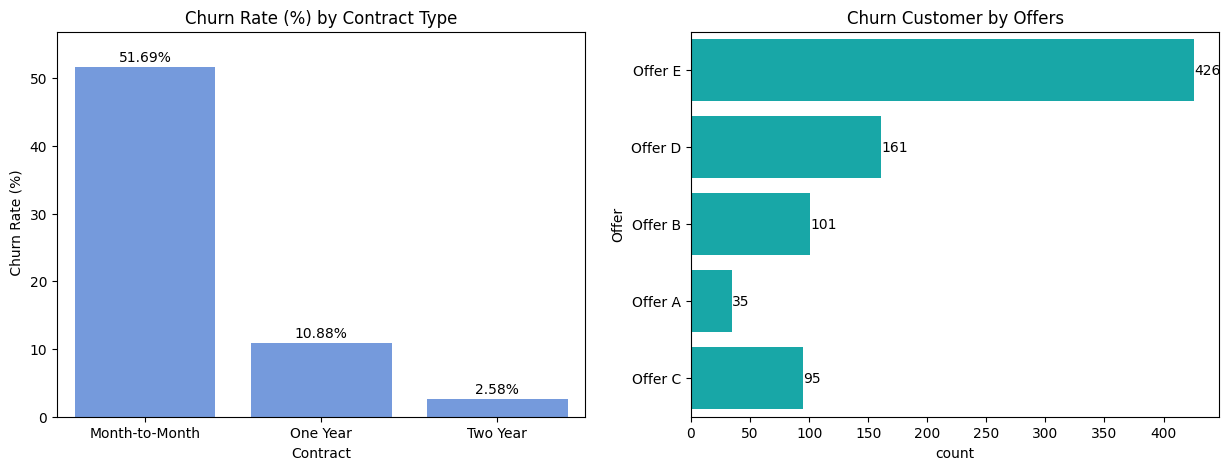

In [140]:
# Churn rate (%) and customer count grouped by contract type
ct = base.groupby('Contract').agg(churn_rate =('churned_flag','mean'),customers =('churned_flag','count')).reset_index()
ct['churn_rate'] = round(ct['churn_rate']*100,2)  # Convert to percentage


fig, axes = plt.subplots(1,2, figsize=(15,5))

a = sns.barplot(data = ct, x = 'Contract', y='churn_rate',color = 'cornflowerblue',ax=axes[0])
for i in a.containers:
  a.bar_label(i,padding=2,fmt='%.2f%%')
axes[0].set_title('Churn Rate (%) by Contract Type')
axes[0].set_ylim(0,ct['churn_rate'].max()*1.1)
axes[0].set_ylabel(' Churn Rate (%)')


b = sns.countplot(data = churned_df, y = 'Offer',color='c',ax=axes[1])
for i in b.containers:
  b.bar_label(i)
axes[1].set_title('Churn Customer by Offers')
plt.show()

**Contracts:** Customers on month-to-month plans are the most likely to cancel, with over half (51.69%) leaving.   

**Offers:** "Offer E" is our worst-performing promotion by far, accounting for the highest number of cancellations (426).

## Phone - Internet and add-on technical services

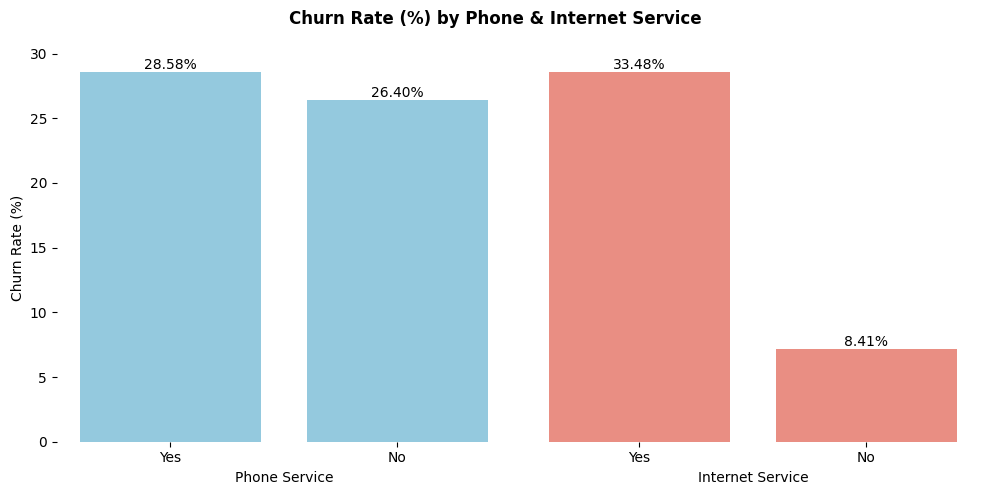

In [141]:
fig, axes = plt.subplots(1,2,figsize=(10,5))

a = sns.barplot( x = base['Phone Service'], y = base['churned_flag']*100, ax = axes[0],ci=None, color='skyblue')
for i in a.containers:
  a.bar_label(i,fmt= '%.2f%%')
axes[0].set_frame_on(False)
axes[0].set_ylabel('Churn Rate (%)')

b = sns.barplot( x = base['Internet Service'], y = base['churned_flag']*100, ax = axes[1],ci=None, color='salmon')
for i in b.containers:
  b.bar_label(i,fmt= '%.2f%%')
axes[1].set_frame_on(False)
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylabel('')
axes[1].set_yticks([])
plt.suptitle('Churn Rate (%) by Phone & Internet Service',weight='bold')
plt.tight_layout()
plt.show()


**Internet Service:** Subscribing to our internet service is a major risk factor for leaving the company entirely, with 33.48% of these users churning compared to just 8.41% of those without it.

**Phone Service:** Having a phone plan barely affects whether a customer stays or leaves, as both groups churn at very similar rates (28.58% vs. 26.40%).

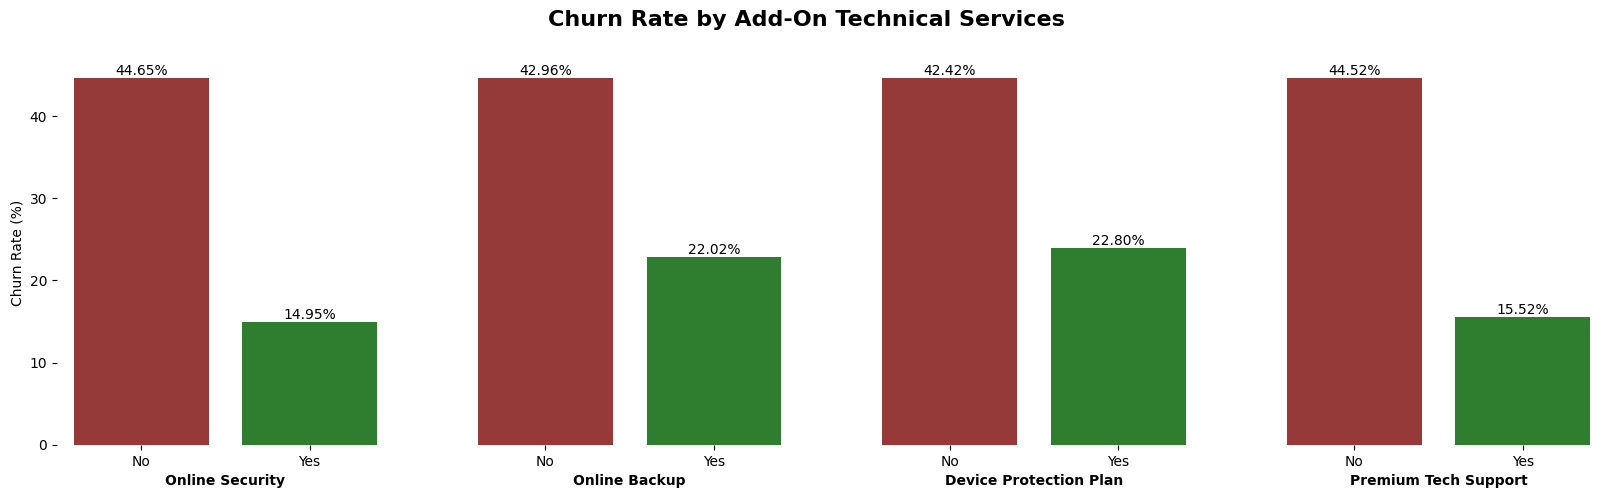

In [142]:
# Churn rate (%) for each internet add-on/protection service subscribed

OS = round(base.groupby('Online Security')['churned_flag'].mean()*100,2).reset_index() # Online Security

OB = round(base.groupby('Online Backup')['churned_flag'].mean()*100,2).reset_index() # Online Backup

DP = round(base.groupby('Device Protection Plan')['churned_flag'].mean()*100,2).reset_index() # Device Protection Plan

PS = round(base.groupby('Premium Tech Support')['churned_flag'].mean()*100,2).reset_index() # Premium Tech Support

# 4-panel comparison chart, one panel per add-on service
plt.figure(figsize=(20,5))
ax = plt.subplot(1,4,1)
a = sns.barplot(data = OS, x = 'Online Security',y='churned_flag',palette=['brown','forestgreen'])
for i in a.containers:
  a.bar_label(i,fmt='%.2f%%')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Online Security',weight='bold')
plt.box(False)


plt.subplot(1,4,2,sharex=ax)
b = sns.barplot(data = OB, x = 'Online Backup',y='churned_flag',palette=['brown','forestgreen'])
for i in b.containers:
  b.bar_label(i,fmt='%.2f%%')
plt.ylabel('')
plt.box(False)
plt.yticks([])
plt.xlabel('Online Backup',weight='bold')

plt.subplot(1,4,3,sharex=ax)
c = sns.barplot(data = DP, x = 'Device Protection Plan',y='churned_flag',palette=['brown','forestgreen'])
for i in c.containers:
  c.bar_label(i,fmt='%.2f%%')
plt.ylabel('')
plt.box(False)
plt.yticks([])
plt.xlabel('Device Protection Plan',weight='bold')

plt.subplot(1,4,4,sharex=ax)
d = sns.barplot(data = PS, x = 'Premium Tech Support',y='churned_flag',palette=['brown','forestgreen'])
for i in d.containers:
  d.bar_label(i,fmt='%.2f%%')
plt.ylabel('')
plt.box(False)
plt.yticks([])
plt.xlabel('Premium Tech Support',weight='bold')

plt.suptitle('Churn Rate by Add-On Technical Services',fontsize=16, fontweight='bold')
plt.show()


**The Add-On Impact:** Customers who do not use extra technical services leave the company at very high rates, consistently above 42%.

**The Best Protections:** Enrolling customers in Online Security or Premium Tech Support is the most effective way to keep them, as it drops the churn rate all the way down to roughly 15% to 22%.


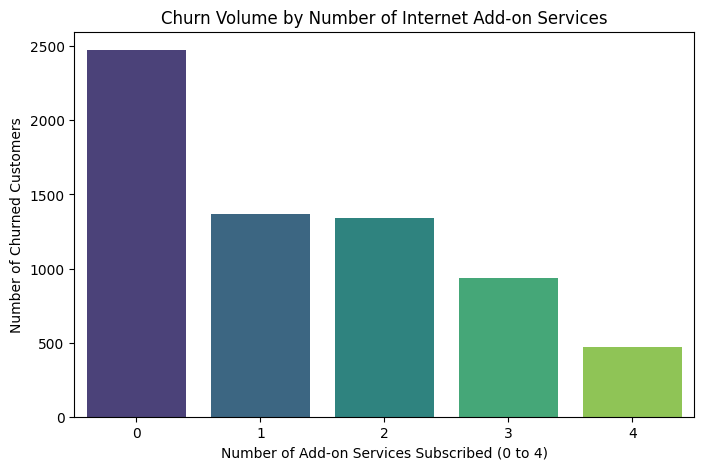

In [143]:
# Total number of protection/support add-ons (0-4) each customer subscribes to
add_ons = ['Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support']

base['add_on_count'] = (base[add_ons] == 'Yes').sum(axis=1)

plt.figure(figsize=(8, 5))
sns.countplot(data=base, x='add_on_count', palette='viridis')

plt.title('Churn Volume by Number of Internet Add-on Services')
plt.xlabel('Number of Add-on Services Subscribed (0 to 4)')
plt.ylabel('Number of Churned Customers')
plt.show()


Customers who do not subscribe to any extra internet services make up the vast majority of cancellations, with nearly 2,500 people leaving.

The more add-on services a customer has, the more likely they are to stay, as the total volume of cancellations drops steadily with each new service they add.

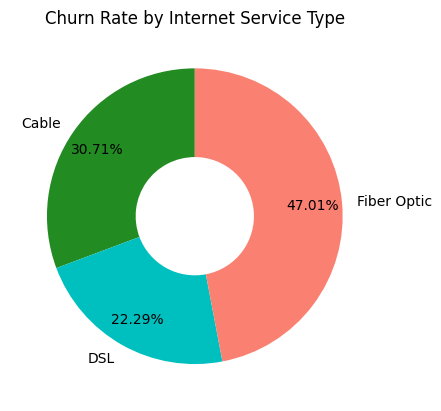

In [144]:
# Churn rate by internet service type (e.g. DSL / Fiber Optic / Cable / None)
base.groupby('Internet Type')['churned_flag'].mean().plot.pie(autopct='%.2f%%',colors=['forestgreen','c','salmon'],startangle=90,pctdistance=0.80,ylabel='',wedgeprops = {'width':0.6})
plt.title('Churn Rate by Internet Service Type')
plt.show()


**Fiber Optic** is the most problematic internet service, driving nearly half (47.01%) of the category's churn.


**DSL** is the most stable option with the lowest churn rate at 22.29%, followed by **Cable** at 30.71%.


## Streaming and other additional services

Streaming includes (TV, Movies, Music).

Additional services are (Multiple Lines, Paperless Billing, Unlimited Data).

In [145]:
# Churn rate (%) by streaming service subscriptions: TV, Movies, Music

print(base.groupby('Streaming TV')['churned_flag'].mean().mul(100).sort_values(ascending=False).round(2))

print('-'* 35)

print(base.groupby('Streaming Movies')['churned_flag'].mean().mul(100).sort_values(ascending=False).round(2))

print('-'* 35)

print(base.groupby('Streaming Music')['churned_flag'].mean().mul(100).sort_values(ascending=False).round(2))


Streaming TV
No     36.41
Yes    30.62
Name: churned_flag, dtype: float64
-----------------------------------
Streaming Movies
No     36.61
Yes    30.49
Name: churned_flag, dtype: float64
-----------------------------------
Streaming Music
No     36.60
Yes    29.89
Name: churned_flag, dtype: float64


In [146]:
# Churn rate (%) by Multiple Lines, Unlimited Data plan, and Paperless Billing status

print(base.groupby('Multiple Lines')['churned_flag'].mean().mul(100).sort_values(ascending=False).round(2))

print('-'* 35)

print(base.groupby('Unlimited Data')['churned_flag'].mean().mul(100).sort_values(ascending=False).round(2))

print('-'* 35)

print(base.groupby('Paperless Billing')['churned_flag'].mean().mul(100).sort_values(ascending=False).round(2))


Multiple Lines
Yes    29.05
No     28.12
Name: churned_flag, dtype: float64
-----------------------------------
Unlimited Data
No     35.08
Yes    33.22
Name: churned_flag, dtype: float64
-----------------------------------
Paperless Billing
Yes    35.23
No     17.93
Name: churned_flag, dtype: float64


## Monthly - Data usage

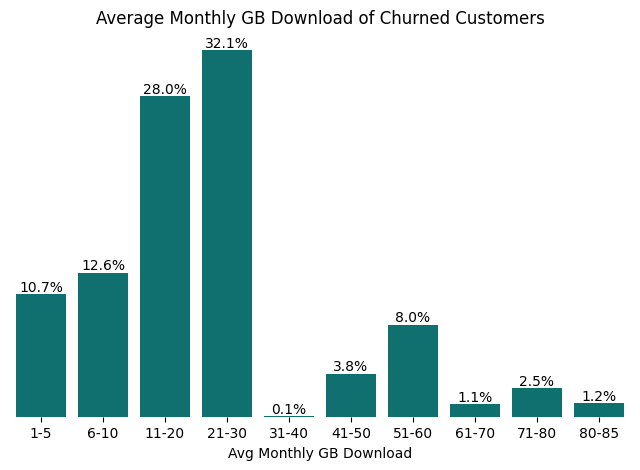

In [147]:
# Bucket 'Avg Monthly GB Download' (for churned customers only) into readable usage ranges

bins = [0, 5, 10, 20, 30, 40, 50, 60, 70, 80, 85]
labels = ['1-5','6-10', '11-20', '21-30', '31-40', '41-50', '51-60','61-70','71-80','80-85']

churned_df['Avg Monthly GB Download'] = pd.cut(churned_df['Avg Monthly GB Download'],bins = bins,labels=labels)

avg_gb = round(churned_df['Avg Monthly GB Download'].value_counts(normalize=True)*100,2).sort_index().reset_index()  # % distribution of churned customers by data-usage bucket

plt.figure(figsize=(8,5))
ax = sns.barplot(data = avg_gb, x = 'Avg Monthly GB Download', y = 'proportion',color ='teal')
for i in ax.containers:
  ax.bar_label(i,fmt='%.1f%%')
plt.box(False)
plt.title('Average Monthly GB Download of Churned Customers')
plt.ylabel('')
plt.yticks([])
plt.show()


**The Danger Zone:** Moderate data users are our biggest churn risk, with 60.1% of all cancellations coming from customers who download between 11 and 30 GB per month.   

**The Loyal Segment:** Heavy internet users (over 30 GB) are much more likely to stay, representing a very small fraction of overall churn.

## Monthly Bill Size and Payment Method

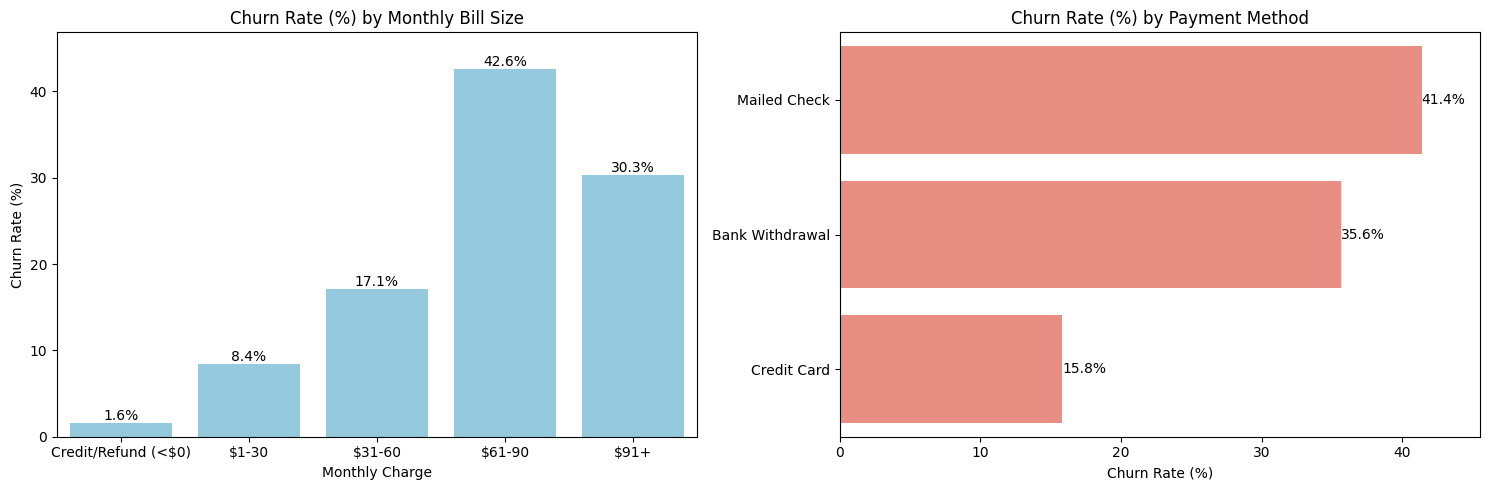

In [148]:
# Bucket monthly charge (for churned customers only) into billing-size ranges

bins = [-np.inf,0,30,60,90,np.inf]
labels = ['Credit/Refund (<$0)','$1-30','$31-60','$61-90','$91+']
churned_df['Monthly Charge'] = pd.cut(churned_df['Monthly Charge'], bins = bins, labels = labels)


monthly_charged = round(churned_df['Monthly Charge'].value_counts(normalize=True)*100,2).sort_index().reset_index(name='pct')

pay_m = (base.groupby('Payment Method')['churned_flag'].mean()*100).round(2).sort_values(ascending=False).reset_index(name='pct')


fig, axes = plt.subplots(1,2,figsize=(15,5))

a = sns.barplot(data = monthly_charged, x = 'Monthly Charge', y = 'pct',color ='skyblue',ax=axes[0])
for i in a.containers:
  a.bar_label(i,fmt='%.1f%%')
axes[0].set_title('Churn Rate (%) by Monthly Bill Size')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0,monthly_charged['pct'].max()*1.1)

b = sns.barplot(data = pay_m, y = 'Payment Method', x = 'pct',color ='salmon',ax=axes[1])
for i in b.containers:
  b.bar_label(i,fmt='%.1f%%')
axes[1].set_title('Churn Rate (%) by Payment Method')
axes[1].set_ylabel('')
axes[1].set_xlabel('Churn Rate (%)')
axes[1].set_xlim(0,pay_m['pct'].max()*1.1)

plt.tight_layout()
plt.show()


**The Price Threshold:** Customers paying between \$61 and \$90 per month are the most likely to leave, with cancellations peaking at 42.6% in this bracket.   

**The Payment Friction:** Manual payments are a major warning sign over 41% of customers who pay by mailed check leave, compared to just 15.8% of those who use a credit card.

#  Financial Impact of Churn

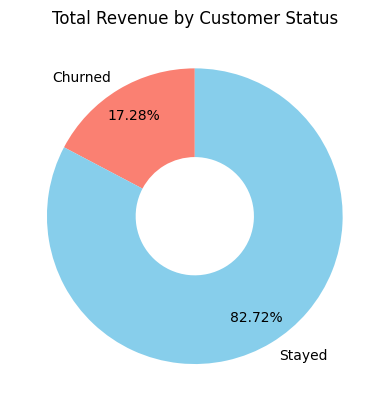


Total Revenue: $21,316,852
Churned Reveune: $3,684,460
Stayed Revenue: $17,632,392


In [149]:
base.groupby('Customer Status')['Total Revenue'].sum().plot.pie(startangle=90, wedgeprops = {'width':0.6},colors = ['salmon','skyblue'],autopct = '%.2f%%',ylabel='',pctdistance=0.8)
plt.title('Total Revenue by Customer Status')
plt.show()

total_revenue = base['Total Revenue'].sum()

# Total lifetime revenue lost to churned customers
churned_revenue = base.loc[base['Customer Status']=='Churned', 'Total Revenue'].sum()

# Total lifetime revenue retained from active customers
stayed_revenue = base.loc[base['Customer Status']=='Stayed', 'Total Revenue'].sum()
print()

print(f'Total Revenue: ${total_revenue:,.0f}')
print(f'Churned Reveune: ${churned_revenue:,.0f}')
print(f'Stayed Revenue: ${stayed_revenue:,.0f}')


## Monthly Bill Size and Payment Method

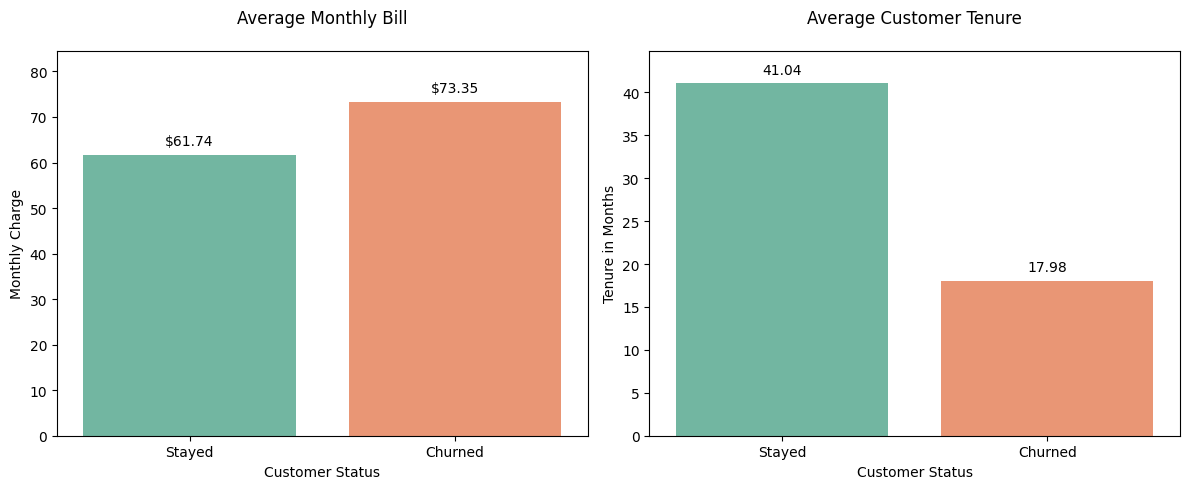

In [150]:
# Compare average monthly bill and average tenure between Churned vs Stayed customers
fig, axes = plt.subplots(1,2,figsize=(12,5))
a = sns.barplot(data = base, x = 'Customer Status', y = 'Monthly Charge',palette='Set2',ax= axes[0],ci=None)
for i in a.containers:
  a.bar_label(i,fmt='$%.2f',padding=5)

axes[0].set_title('Average Monthly Bill',pad =20)
axes[0].set_ylim(0, base['Monthly Charge'].mean()*1.3)
b = sns.barplot(data = base, x = 'Customer Status', y = 'Tenure in Months',palette='Set2',ax= axes[1],ci=None)
for i in b.containers:
  b.bar_label(i,fmt = '%.2f',padding=5)

axes[1].set_title('Average Customer Tenure',pad =20)
axes[1].set_ylim(0, base['Tenure in Months'].mean()*1.3)
plt.tight_layout()
plt.show()


**Higher Bills Drive Churn:** Churn customers are more likely to pay more, with an average monthly bill of \$73.35 compared to the \$61.74 paid by those who stay.

**The Early Exit:** Customers who leave usually do so much earlier in their lifecycle, staying for an average of just 17.98 months compared to the 41-month average of loyal users

# Top-5 Cities by Customer status

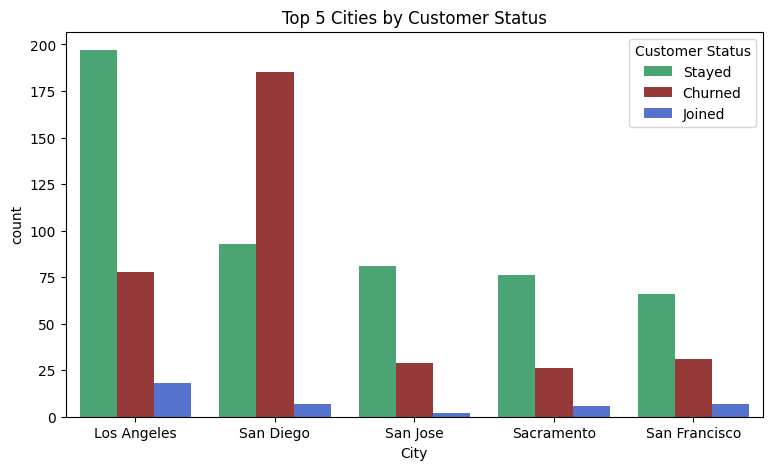

In [151]:
plt.figure(figsize=(9,5))
sns.countplot(data=df,hue='Customer Status',x='City',order = df['City'].value_counts().index[:5],palette=['mediumseagreen','brown','royalblue'])
plt.title('Top 5 Cities by Customer Status')
plt.show()


San Diego is experiencing a severe retention crisis, with roughly twice as many customers canceling their service as staying.

Even though Los Angeles has the highest total count of loyal users, it is still losing about 27% of its customer base, meaning a massive volume of people are leaving our biggest market.

# Risk Segmentation

Combining the strongest churn signals found above (short tenure, flexible/no-commitment
contracts, and no protective add-ons) into a single actionable "High-Risk" customer segment
that the business can target for proactive retention.

In [152]:
# Defining High Risk Segment:
base['High_risk'] = np.where((base['Tenure in Months'] <6) &
                            (base['Contract']=='Month-to-Month') &
                            (base['add_on_count']==0),'Yes','No' )

risk_summary = base.groupby('High_risk').agg(churn_rate = ('churned_flag','mean'),
                              customer_count = ('churned_flag','count'))

risk_summary['churn_rate'] = (risk_summary['churn_rate']*100).round(2)

total_churned = (base['churned_flag']==1).sum()

high_risk_churned = base.loc[(base['High_risk'] == 'Yes') &
                        (base['churned_flag']==1)].shape[0]  # Number of churned customers that fall inside the High-Risk segment

high_risk_size_pct = round((base['High_risk']=='Yes').mean() * 100, 2)  # What % of the whole customer base is flagged High-Risk

pct_of_total_churn = round(high_risk_churned/total_churned *100, 2)  # What % of churned customer was in high risk segment
# 'total_churned' is referenced here as the total number of churned customers

print(risk_summary)
print()
print(f'Total Churned: {total_churned}')
print(f"High-Risk segment makes up {high_risk_size_pct}% of the user base, but accounts for {pct_of_total_churn}% of total churn.")


           churn_rate  customer_count
High_risk                            
No              22.79            6025
Yes             87.94             564

Total Churned: 1869
High-Risk segment makes up 8.56% of the user base, but accounts for 26.54% of total churn.


## High Risk VS Standard Customers

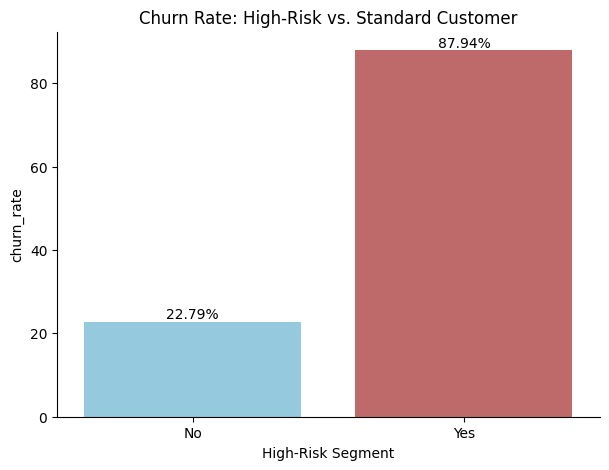

High-Risk Segment (Month-to-Month + <6 Months Tenure + 0 Add-Ons)


In [153]:
plt.figure(figsize=(7,5))
ax = sns.barplot(data=risk_summary, x='High_risk', y='churn_rate',
                  palette=['skyblue','indianred'])
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f%%')
plt.title('Churn Rate: High-Risk vs. Standard Customer')
plt.xlabel('High-Risk Segment')
sns.despine()
plt.show()
print('High-Risk Segment (Month-to-Month + <6 Months Tenure + 0 Add-Ons)')

Customers who fall into our specific high-risk bucket (recently joined, on a monthly plan, and using zero add-ons) are almost guaranteed to leave, with a massive 87.94% churn rate.   

Customers outside of this high-risk group are nearly four times more likely to stay, dropping the churn rate to a much more manageable 22.79%.

# Correlation Matrix of Numerical Features

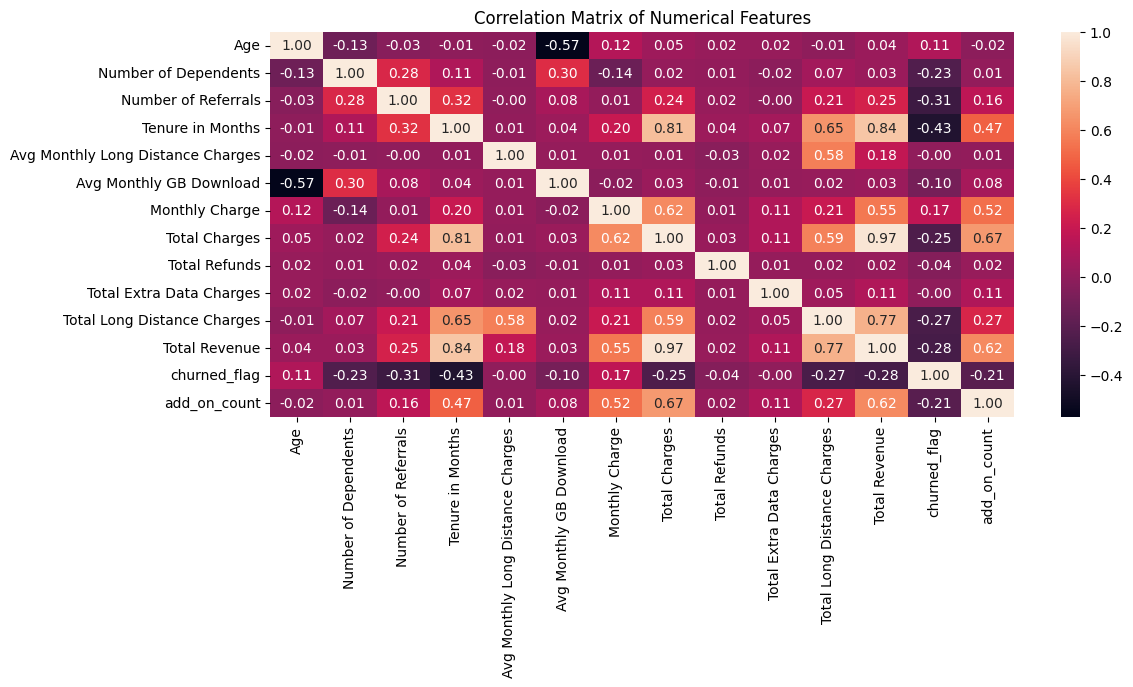

In [154]:
# Correlation heatmap across all numerical features

plt.figure(figsize=(12,5))
sns.heatmap(base.corr(numeric_only=True),annot=True,fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()


- (Tenure in Months) has the strongest negative correlation with churn (-0.43), mathematically proving that the longer a customer stays, the less likely they are to leave.
- Number of Referrals (-0.31) and Number of Dependents (-0.23) both show moderate negative correlations with churn
- (add_on_count) also has a negative correlation with churn (-0.21),validating that stacking extra services increases retention.



# Key Insights

1. **Contract type is the single strongest churn driver.** Month-to-Month customers churn at a
   dramatically higher rate than One-Year or Two-Year contract holders, since they have no
   commitment or switching cost.
2. **Churn is front-loaded in the customer lifecycle.** The highest churn rates occur in the first
   1–6 months of tenure and drop off sharply the longer a customer stays the early relationship
   is the highest-risk (and highest-opportunity) window.
3. **Competitor offers and service/support quality are the leading churn reasons.** The top
   `Churn Category`/`Churn Reason` values point to competitors offering better devices, better
   pricing/data, and to dissatisfaction with company support/attitude.
4. **Add-on services correlate with lower churn.** Customers without Online Security, Online
   Backup, Device Protection, or Premium Tech Support churn at a notably higher rate than those
   with these add-ons.
5. **Fiber-optic internet customers show a higher churn rate** than DSL/Cable customers, worth
   investigating from a service-quality or pricing-competitiveness angle.
6. **Losing customers is costing us a lot of money**.
The people who cancel are taking a massive chunk of our overall revenue with them. This proves that spending money to keep current customers happy is just as important as finding new ones.
7. **A small, well-defined High-Risk segment (Month-to-Month + <6 months tenure + zero add-ons).**

    Most of the people quitting belong to one specific group (Brand-new users on Monthly plans) who haven't added any extra features. Because this group is small but causes so much damage, we can fix the majority of our churn problem just by focusing our efforts and budget on them.





# Business Recommendations

- **Target the High-Risk segment with a proactive "first 6 months" retention program**  Give them personalized setup help, check-in calls, or special discounts early on, so they feel valued before they ever think about canceling.
- **Encourage users to sign longer contracts** Offer our monthly customers a discount or special perk to switch to a 1- or 2-year plan, since being on a monthly plan is the biggest reason people leave.
- **Include extra features for free in the beginning.** Give new customers add-ons (like Security, Backup, or Tech Support) for free or very cheap during their first few months. The data shows that people who use these features rarely quit.
- **Investigate and address the competitive and support-quality drivers of churn** identified in
  the churn-reason analysis (device/offer competitiveness, staff attitude) via a dedicated retention
  or win-back task force.
- **Review fiber-optic pricing and service quality** because it is losing customers faster than our other internet options.
- **Focus our budget on saving our most profitable customers.** When deciding who gets special offers to stay, prioritize the customers who spend the most money with us, rather than just treating everyone who might leave the same.
